### Fourier Transform

Theory details can be found in this [blog](https://www.zhihu.com/question/21665935)

Important insights
- Fourier Series means using a series of sines and cosines to fit a __Periodic__ function; Fourier Transform use a series of complex exponentials to fit a __Non-Periodic__ function, the core idea of Fourier Transform is to consider a non-periodic function as a periodic funtion with infinite period length.
- After Fourier Transform, we will get a frequency spectrum, the coordinate (x, y) means (frequency, amplitude of that wave)

---

In [22]:
import numpy as np
import matplotlib.pyplot as plt

In [23]:
def fourier_transform(x):
	"""
	Compute the Discrete Fourier Transform of a 1D array.
    
	Parameters:
	x (np.ndarray): Input array of complex or real numbers (time domain)
    
	Returns:
	np.ndarray: discrete Fourier transform of the input array (frequency domain)
	"""
    
	x = np.asarray(x, dtype=complex)
	N = x.shape[0]
	n = np.arange(N)
	k = n.reshape((N, 1))
	C_n = np.exp(-2j * np.pi * k * n / N)
	return C_n @ x

In [24]:
def inverse_fourier_transform(X):
    """
    Compute the Inverse Discrete Fourier Transform (IDFT) of a 1D array.

    Parameters:
    X (np.ndarray): Frequency domain data (complex values)

    Returns:
    np.ndarray: Time domain signal (complex, real if original was real)
    """
    X = np.asarray(X, dtype=complex)
    N = X.shape[0]
    k = np.arange(N)
    n = k.reshape((N, 1))

    # IDFT matrix with + sign in exponent
    M = np.exp(2j * np.pi * k * n / N)

    # Divide by N to normalize
    return (1 / N) * M @ X

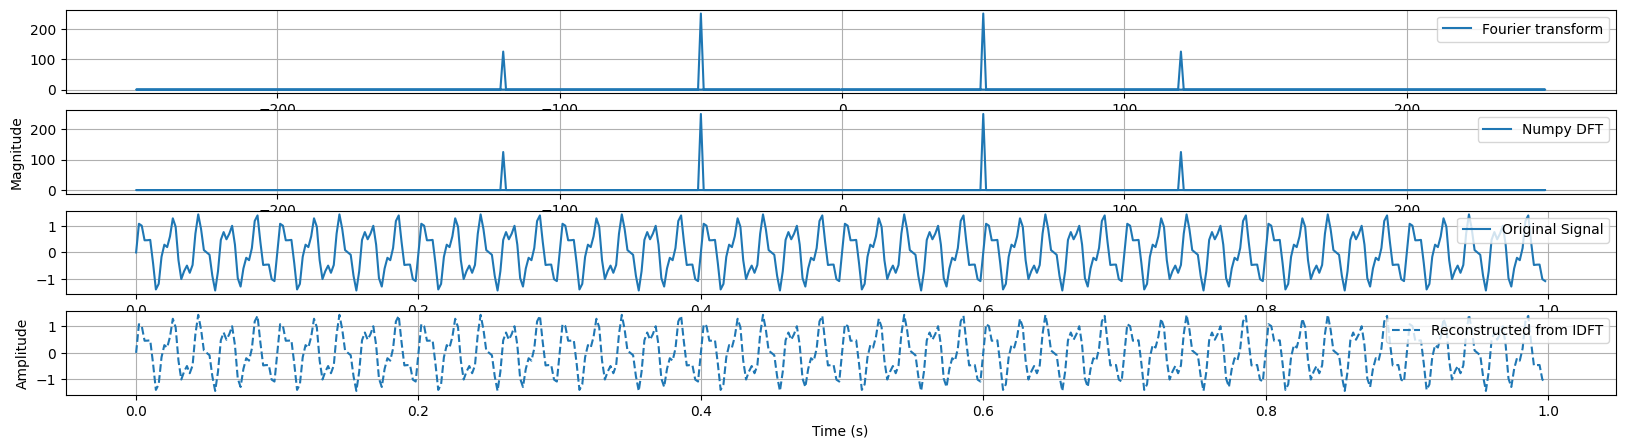

In [25]:
# Example sigal: sum of two sine waves

Fs = 500 # sampling frequency (Hz)
T = 1    # duration is seconds
t = np.linspace(0, T, int(T*Fs), endpoint=False)

# Create a signal with two frequencies: 50Hz and 120Hz
f1, f2 = 50, 120
signal = np.sin(2*np.pi*f1*t) + 0.5 * np.sin(2*np.pi*f2*t)

# Compute DFT
X = fourier_transform(signal)
reconstructed_signal = np.real(inverse_fourier_transform(X))

# Frequency axis
freqs = np.fft.fftfreq(len(t), 1/Fs)

# Compare with numpy's implementation of DFT
X_np = np.fft.fft(signal)

# Plot the magnitude spectrum
plt.figure(figsize=(20, 5))

plt.subplot(4, 1, 1)
plt.plot(freqs, np.abs(X), label='Fourier transform')
plt.legend()
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(freqs, np.abs(X_np), label='Numpy DFT')
plt.legend()
plt.grid()

plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')

plt.subplot(4, 1, 3)
plt.plot(t, signal, label="Original Signal")
plt.legend()
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(t, reconstructed_signal, linestyle='dashed', label="Reconstructed from IDFT")
plt.legend()
plt.grid()

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.show()